In [ ]:
import duckdb
from pprint import pprint
import os
from db import get_connection, get_schema_summary, execute_query
from prompts import build_sql_prompt, build_presentation_prompt_short, build_presentation_type_prompt, build_presentation_prompt_df
from prompts import build_chart_prompt, CHART_SCHEMA
from eval import TEST_CASES, PLOT_TEST_CASES, PLOT_TEST_CASES2
from openai import OpenAI
import matplotlib.pyplot as plt
import numpy as np
 


In [2]:
# Connect to the DuckDB database
db_path = '../data/jaffle_shop.duckdb'
conn = duckdb.connect(db_path)
print(f"Connected to {db_path}")

Connected to ../data/jaffle_shop.duckdb


In [3]:
schema_summary = get_schema_summary(conn)
print("Database Schema Summary:")
print(schema_summary)


Database Schema Summary:
customers
  - customer_id: INTEGER
  - first_name: VARCHAR
  - last_name: VARCHAR
  - email: VARCHAR
  - loyalty_tier: VARCHAR
  - created_at: TIMESTAMP

order_items
  - order_item_id: INTEGER
  - order_id: INTEGER
  - product_id: INTEGER
  - quantity: INTEGER
  - unit_price: DECIMAL(8,2)
  - line_total: DECIMAL(10,2)

orders
  - order_id: INTEGER
  - customer_id: INTEGER
  - order_date: DATE
  - status: VARCHAR
  - total_amount: DECIMAL(10,2)
  - order_channel: VARCHAR

products
  - product_id: INTEGER
  - product_name: VARCHAR
  - category: VARCHAR
  - price: DECIMAL(8,2)
  - description: VARCHAR


In [4]:
special_columns = [{"name": "status", "table": "orders"}, {"name": "loyalty_tier", "table": "customers"}]
special_columns_results = []
for col in special_columns:
    #print(f"Unique values for {col['table']}.{col['name']}:")
    query = f"SELECT DISTINCT {col['name']} FROM {col['table']}"
    result = execute_query(query, conn)
    #print(result.to_string(index=False))

    special_columns_results.append({
        "column": f"{col['table']}.{col['name']}",
        "values": result[col['name']].tolist()
    })

print("Special columns and their unique values:")
pprint(special_columns_results)
# status_categories = execute_query("SELECT status from orders group by status", conn)
# loyalty_tier_categories = execute_query("SELECT loyalty_tier from customers group by loyalty_tier", conn)
# print("orders.status values:")
# print(status_categories.to_string(index=False))
# print("customers.loyalty_tier values:")
# print(loyalty_tier_categories.to_string(index=False))

Special columns and their unique values:
[{'column': 'orders.status', 'values': ['cancelled', 'returned', 'completed']},
 {'column': 'customers.loyalty_tier',
  'values': ['bronze', 'platinum', 'gold', 'silver']}]


In [5]:

test_case = TEST_CASES[0]
pprint(test_case)
question = test_case["question"]
prompt = build_sql_prompt(question, schema_summary, special_columns = special_columns_results)

{'category': 'answerable',
 'expected_behavior': 'Returns a single total count of orders.',
 'expected_sql_contains': ['count', 'from'],
 'id': 'tc_01',
 'notes': 'Basic sanity check. Should be the easiest case.',
 'question': 'How many orders do we have in total?'}


In [6]:
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))
response = client.chat.completions.create(
    model="gpt-4o",
    messages=[{"role": "user", "content": prompt}])

print("Generated SQL:")
print(response.choices[0].message.content)


Generated SQL:
SELECT COUNT(*) AS total_orders FROM orders;


In [7]:
result = execute_query(response.choices[0].message.content, conn=conn)
print("Query Result:")
print(result)


Query Result:
   total_orders
0          3000


In [3]:
from agent import DatabaseAgent
for test_case in TEST_CASES[3:4]:
    question = test_case["question"]
    print(f"Question: {question}")
    agent = DatabaseAgent(conn, log=print)
    response = agent(question)
    print("Agent response:")
    print(response)
    if response["success"]:
        print(response["text"])
        if response["presentation_type"] == "TABLE" and response.get("chart", None):
            fig, ax = response["chart"]
            fig.show()
            plt.close(fig)  # Close the figure after showing it to free up resources
        


Question: Who are our top 10 customers by total spend?
Generated SQL:
SELECT c.customer_id, c.first_name, c.last_name, SUM(o.total_amount) AS total_spend
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_id, c.first_name, c.last_name
ORDER BY total_spend DESC
LIMIT 10
The following DataFrame presents the top 10 customers ranked by their total spending. This information was retrieved by aggregating order amounts from the orders placed by each customer.

 customer_id first_name last_name  total_spend
         152       Luna    Wright        547.0
         183     Olivia  Thompson        537.5
          97     Olivia     Smith        518.5
          11       Ella      Hill        508.0
         173    William    Thomas        492.0
          93    William     Moore        488.0
         102      Jacob  Martinez        486.0
         182      Caleb      Hill        470.5
         195       Jack     Moore        469.0
          54      Logan  Anderson      

BadRequestError: Error code: 400 - {'error': {'message': "Missing required parameter: 'text.format.name'.", 'type': 'invalid_request_error', 'param': 'text.format.name', 'code': 'missing_required_parameter'}}


X--------------------------------------------------X
X--------------------------------------------------X
X--------------------------------------------------X

{'category': 'plotting',
 'expected_behavior': 'Returns monthly revenue and chooses a line chart.',
 'expected_chart_fields': {'x': 'month', 'y': ['monthly_revenue']},
 'expected_chart_type': 'line',
 'id': 'plot_01',
 'notes': 'Basic time-series case.',
 'question': 'What was our monthly revenue over time?'}
DataFrame Presentation Output:
The query provides a summary of the monthly revenue generated over time by aggregating the total sales amount from customer orders. The data is grouped by month and sorted chronologically to help analyze revenue trends. Below is the DataFrame reflecting the monthly revenue.
     month  monthly_revenue
2024-01-01           2219.5
2024-02-01           1784.5
2024-03-01           2287.0
2024-04-01           1960.0
2024-05-01           2063.0
2024-06-01           2376.0
2024-07-01           2771.

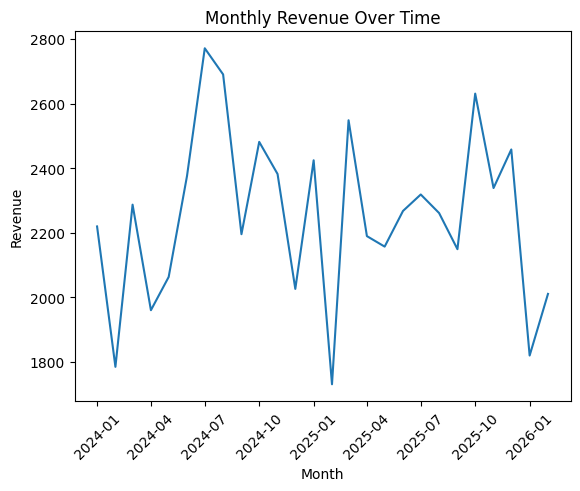


X--------------------------------------------------X
X--------------------------------------------------X
X--------------------------------------------------X

{'category': 'plotting',
 'expected_behavior': 'Returns monthly revenue and order count and chooses a '
                      'multi-line chart.',
 'expected_chart_fields': {'x': 'month',
                           'y': ['monthly_revenue', 'order_count']},
 'expected_chart_type': 'line',
 'id': 'plot_02',
 'notes': 'Several y-values on one line plot.',
 'question': 'Show monthly revenue and order count over time.'}
DataFrame Presentation Output:
The following DataFrame presents a summary of the monthly revenue and the count of orders over time. The revenue and order counts have been aggregated on a monthly basis to provide insights into trends and patterns in sales performance over the observed period.
     month  monthly_revenue  order_count
2024-01-01           2219.5          111
2024-02-01           1784.5           94
2024

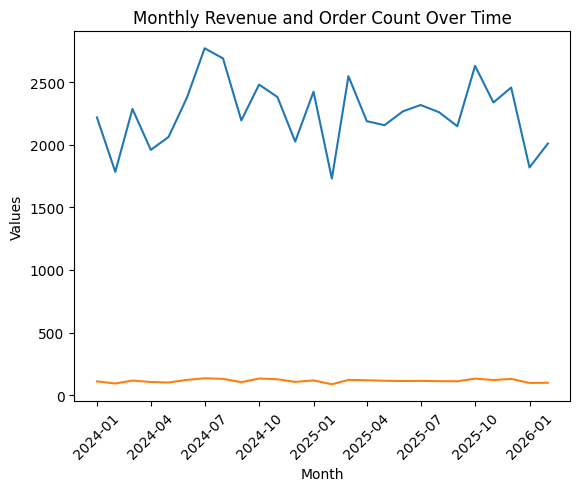


X--------------------------------------------------X
X--------------------------------------------------X
X--------------------------------------------------X

{'category': 'plotting',
 'expected_behavior': 'Returns ranked products and chooses a bar chart.',
 'expected_chart_fields': {'x': 'product_name', 'y': 'total_revenue'},
 'expected_chart_type': 'bar',
 'id': 'plot_03',
 'notes': 'Classic category comparison.',
 'question': 'What are the top 10 products by revenue?'}
DataFrame Presentation Output:
The following DataFrame showcases the top 10 products ranked by their total revenue. The data was aggregated from order item details and includes both the product identifiers and names alongside their respective revenue totals.
 product_id           product_name  total_revenue
          4      Spicy Beef Jaffle         5984.0
          3     BBQ Chicken Jaffle         5785.5
          5 Mushroom & Brie Jaffle         5410.0
          2          Veggie Jaffle         5184.0
          6 

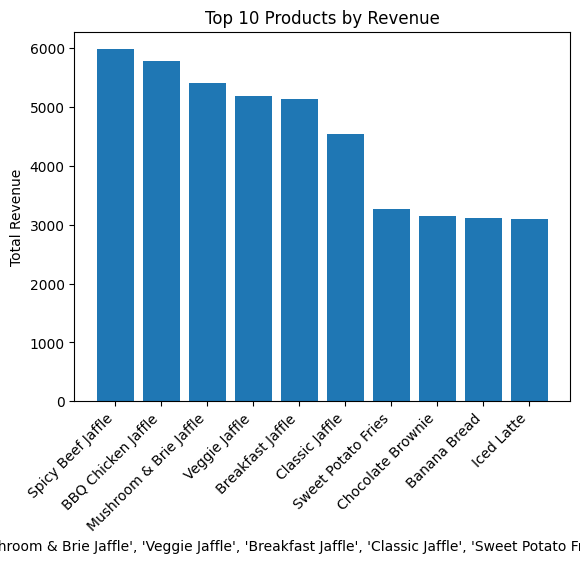


X--------------------------------------------------X
X--------------------------------------------------X
X--------------------------------------------------X

{'category': 'plotting',
 'expected_behavior': 'Returns revenue split by year and product and chooses a '
                      'grouped bar chart.',
 'expected_chart_fields': {'group': 'product_name',
                           'x': 'year',
                           'y': 'total_revenue'},
 'expected_chart_type': 'grouped_bar',
 'id': 'plot_04',
 'notes': 'Multi-level category comparison.',
 'question': 'Show revenue by year and product.'}
DataFrame Presentation Output:
The following data frame presents the revenue generated by each product, categorized by year. It offers insights into the financial performance of various products over time, aiding in the analysis of sales trends and the identification of revenue contributors.
 year           product_name  revenue
 2024     BBQ Chicken Jaffle   2761.5
 2024      Spicy Beef Jaf

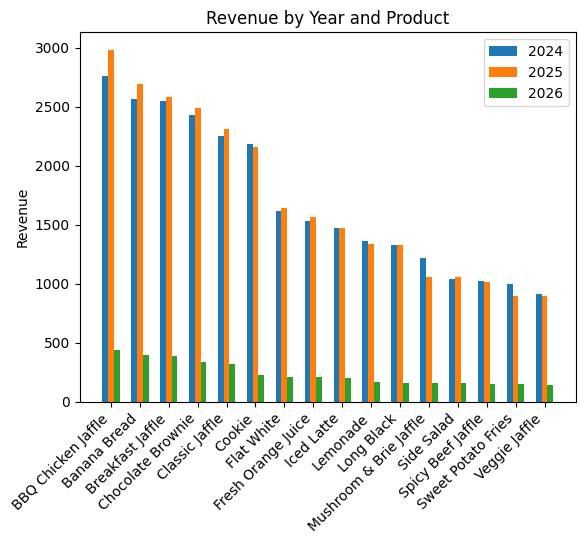


X--------------------------------------------------X
X--------------------------------------------------X
X--------------------------------------------------X

{'category': 'plotting',
 'expected_behavior': 'Returns revenue by year and product and chooses a '
                      'stacked bar chart.',
 'expected_chart_fields': {'stack': 'product_name',
                           'x': 'year',
                           'y': 'total_revenue'},
 'expected_chart_type': 'stacked_bar',
 'id': 'plot_05',
 'notes': 'Composition across years.',
 'question': 'Show the composition of revenue by year across products.'}
DataFrame Presentation Output:
The following data presents an analysis of revenue composition by year across different products, detailing the contribution of each product to the annual revenue. This data allows us to observe trends and shifts in product sales over time.
 year           product_name  revenue
 2024     BBQ Chicken Jaffle   2761.5
 2024      Spicy Beef Jaffle   2563.

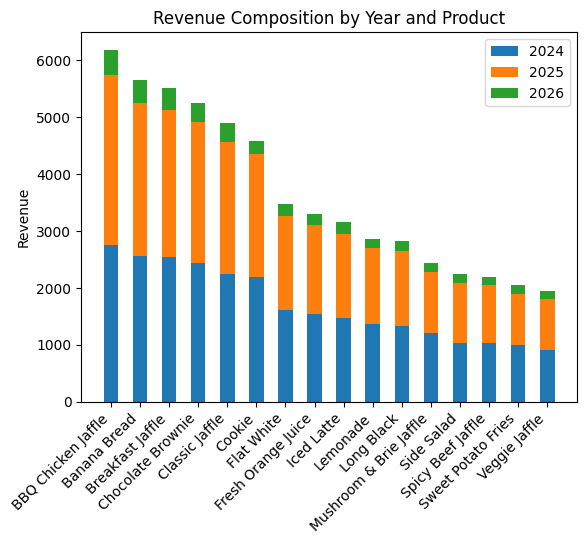


X--------------------------------------------------X
X--------------------------------------------------X
X--------------------------------------------------X

{'category': 'plotting',
 'expected_behavior': 'Returns monthly completed order counts and chooses a '
                      'line chart.',
 'expected_chart_fields': {'x': 'month', 'y': ['completed_orders']},
 'expected_chart_type': 'line',
 'id': 'plot_06',
 'notes': 'Time-series counts.',
 'question': 'How many completed orders did we have by month?'}
DataFrame Presentation Output:
The following data provides a monthly summary of the number of completed orders, based on the order completion status in the database.
order_month  completed_orders_count
 2024-01-01                     100
 2024-02-01                      77
 2024-03-01                     101
 2024-04-01                      93
 2024-05-01                      89
 2024-06-01                     104
 2024-07-01                     122
 2024-08-01                  

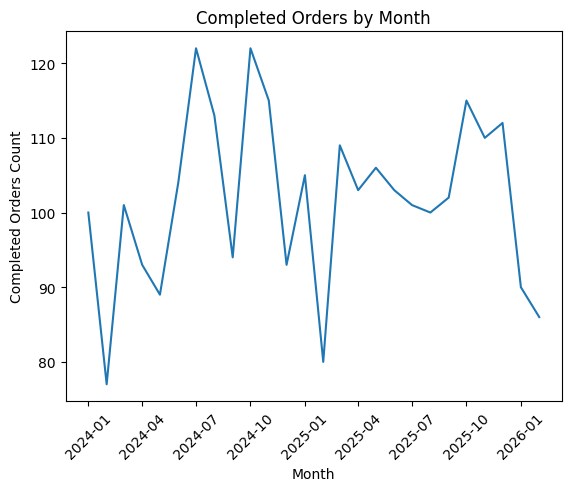


X--------------------------------------------------X
X--------------------------------------------------X
X--------------------------------------------------X

{'category': 'plotting',
 'expected_behavior': 'Returns monthly revenue split by category and chooses a '
                      'grouped line chart.',
 'expected_chart_fields': {'group': 'category',
                           'x': 'month',
                           'y': ['monthly_revenue']},
 'expected_chart_type': 'line_grouped',
 'id': 'plot_07',
 'notes': 'Core line_grouped case: one metric over time split by category.',
 'question': 'Show monthly revenue by product category.'}
DataFrame Presentation Output:
The displayed dataset summarizes the monthly revenue for each product category. This analysis provides insights into the financial performance and trends of different categories over time, allowing for more informed decision-making based on sales patterns. Below is the breakdown of the revenue by month and category.
  m

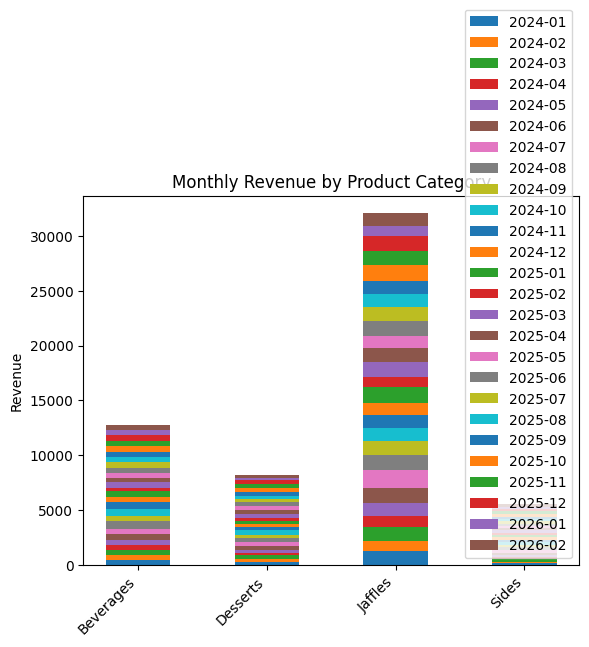


X--------------------------------------------------X
X--------------------------------------------------X
X--------------------------------------------------X

{'category': 'plotting',
 'expected_behavior': 'Returns monthly order counts split by status and '
                      'chooses a grouped line chart.',
 'expected_chart_fields': {'group': 'status',
                           'x': 'month',
                           'y': ['order_count']},
 'expected_chart_type': 'line_grouped',
 'id': 'plot_08',
 'notes': 'Another line_grouped case with a business grouping variable.',
 'question': 'Show monthly order count by order status.'}
DataFrame Presentation Output:
The data presented below summarizes the monthly order count categorized by the status of orders. This breakdown provides insights into how order statuses vary over time on a monthly basis.
     month    status  order_count
2024-01-01 cancelled            5
2024-01-01 completed          100
2024-01-01  returned            6
20

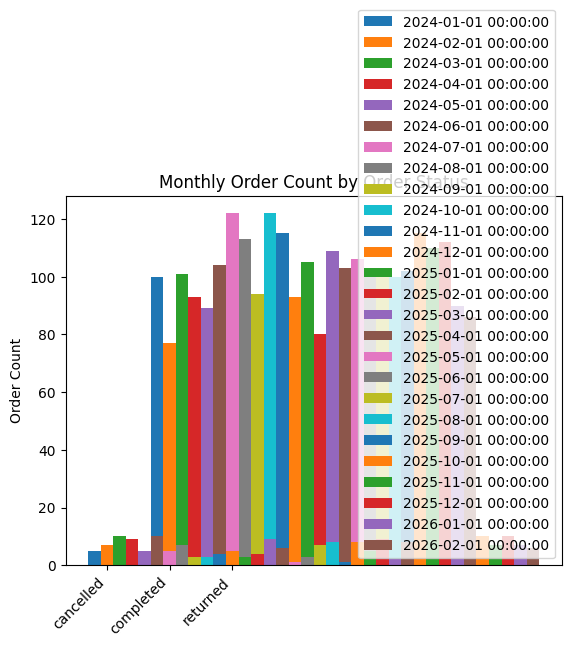


X--------------------------------------------------X
X--------------------------------------------------X
X--------------------------------------------------X

{'category': 'plotting',
 'expected_behavior': 'Returns monthly revenue split by product and chooses a '
                      'grouped line chart if the number of products is '
                      'manageable.',
 'expected_chart_fields': {'group': 'product_name',
                           'x': 'month',
                           'y': ['monthly_revenue']},
 'expected_chart_type': 'line_grouped',
 'id': 'plot_09',
 'notes': 'Useful stress case; may be too busy if many products.',
 'question': 'Show monthly revenue by product.'}
DataFrame Presentation Output:
The following DataFrame presents the monthly revenue generated by each product. It is derived from an analysis of order data, with revenue figures aggregated on a monthly basis and organized by product name.
     month           product_name  monthly_revenue
2024-01-01   

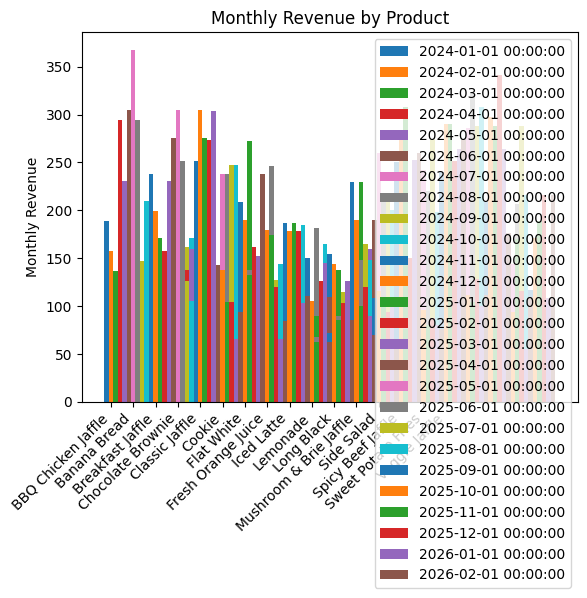


X--------------------------------------------------X
X--------------------------------------------------X
X--------------------------------------------------X

{'category': 'plotting',
 'expected_behavior': 'Either chooses line_grouped with one metric, or none if '
                      'the result is too complex to visualize cleanly in the '
                      'allowed schema.',
 'expected_chart_fields': {'group': 'category',
                           'x': 'month',
                           'y': ['monthly_revenue']},
 'expected_chart_type': 'line_grouped',
 'id': 'plot_10',
 'notes': 'Good edge case: your schema does not handle grouped multi-metric '
          'lines very well.',
 'question': 'Compare revenue and completed orders by month for each product '
             'category.'}
DataFrame Presentation Output:
The analysis aims to evaluate the monthly revenue and the number of completed orders for each product category. By aggregating the data from the orders, order items, an

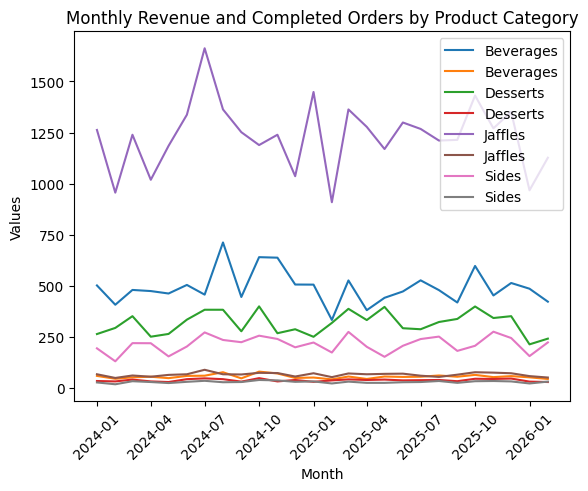


X--------------------------------------------------X
X--------------------------------------------------X
X--------------------------------------------------X

{'category': 'no_plot',
 'expected_behavior': 'Returns a single total and chooses no chart.',
 'expected_chart_fields': {},
 'expected_chart_type': 'none',
 'id': 'plot_11',
 'notes': 'Single scalar result.',
 'question': 'How many orders do we have in total?'}
Text Output:
The total number of orders is 3,000.

X--------------------------------------------------X
X--------------------------------------------------X
X--------------------------------------------------X

{'category': 'no_plot',
 'expected_behavior': 'Returns one scalar and chooses no chart.',
 'expected_chart_fields': {},
 'expected_chart_type': 'none',
 'id': 'plot_12',
 'notes': 'Another scalar no-plot case.',
 'question': 'What is the average order value overall?'}
Text Output:
The average order value overall is 19.5135.

X--------------------------------------

In [ ]:
for test_case in PLOT_TEST_CASES2:
    print("\nX--------------------------------------------------X")
    print("X--------------------------------------------------X")
    print("X--------------------------------------------------X\n")
    pprint(test_case)
    question = test_case["question"]
    prompt = build_sql_prompt(question, schema_summary)

    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[{"role": "user", "content": prompt}])

    generated_SQL = response.choices[0].message.content
    # if generated_SQL.upper().startswith("AMBIGUOUS"):
    #     print("The question is ambiguous and could have multiple valid interpretations.")
    #     print("Reason:", generated_SQL.split(":", 1)[1].strip())
    # elif generated_SQL.upper().startswith("UNANSWERABLE"):
    #     print("The question is unanswerable based on the provided schema and data.")
    #     print("Reason:", generated_SQL.split(":", 1)[1].strip())        
       
    # else:                  
    #print("Generated SQL:")
    #print(generated_SQL)
    if generated_SQL.upper().startswith("AMBIGUOUS") or generated_SQL.upper().startswith("UNANSWERABLE"):
        print("Skipping execution due to ambiguity or unanswerability.")
        continue
    try: 
        result = execute_query(response.choices[0].message.content, conn=conn)
    except Exception as e:
        #print("Error executing query:", e)
        result = None
        error = e
    #print(result.to_string(index=False))

    if result is not None: 
        result_columns_and_DT_dict = {col: str(dtype) for col, dtype in zip(result.columns, result.dtypes)}
        #print("Result Columns:")
        #print(result_columns_and_DT_dict)
        presentation_type_prompt = build_presentation_type_prompt(question, schema_summary, generated_SQL, result)
        presentation_response = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": presentation_type_prompt}])
        presentation_type = presentation_response.choices[0].message.content.strip()
        #print("Determined Presentation Type:")
        #print(presentation_type)

        if presentation_type == "PRESENTATION: TEXT":
            to_text_prompt = build_presentation_prompt_short(question, schema_summary, generated_SQL, result.head())
            text_response = client.chat.completions.create(
                model="gpt-4o",
                messages=[{"role": "user", "content": to_text_prompt}])
            text_output = text_response.choices[0].message.content
            print("Text Output:")
            print(text_output)
        if presentation_type == "PRESENTATION: TABLE":
            df_presentation_prompt = build_presentation_prompt_df(question, schema_summary, generated_SQL, result.head())
            #print("DataFrame Presentation Prompt:")
            #print(df_presentation_prompt)
            df_response = client.chat.completions.create(
                model="gpt-4o",
                messages=[{"role": "user", "content": df_presentation_prompt}])
            df_output = df_response.choices[0].message.content
            print("DataFrame Presentation Output:")
            print(df_output)
            print(result.to_string(index=False))
            
            chart_prompt = build_chart_prompt(question=question, sql=generated_SQL, columns=result_columns_and_DT_dict, preview_rows=result.head())
            #print("Chart Prompt:")
            #print(chart_prompt)
            chart_response = client.responses.create(
                model="gpt-4o",
                input=chart_prompt,
                text={
                    "format": {
                        "type": "json_schema",
                        "name": "chart_spec",
                        "strict": True,
                        "schema": CHART_SCHEMA
                    }
                }
            )

            chart_output_raw = chart_response.output_text
            print("Chart Output:")
            print(chart_output_raw)
            import json
            chart_output_dict = json.loads(chart_output_raw.strip())
            match chart_output_dict.get("chart_type", "").lower():
                case "bar":
                    print("Interpreted as BAR chart with the following details:")
                    print(chart_output_dict)
                    fig, ax = plt.subplots()
                    x_labels = result[chart_output_dict["x"]].astype(str).tolist()
                    x_pos = np.arange(len(x_labels))

                    ax.bar(result[chart_output_dict["x"]], result[chart_output_dict["y"]])
                    ax.set_xlabel(x_labels)
                    ax.set_ylabel(chart_output_dict["ylabel"])
                    ax.set_title(chart_output_dict["title"])
                    ax.set_xticks(x_pos)
                    ax.set_xticklabels(x_labels, rotation=45, ha="right")
                    plt.show()
                    plt.close()
                case "grouped_bar":   
                    print("Interpreted as GROUPED BAR chart with the following details:")
                    pprint(chart_output_dict)
                    fig, ax = plt.subplots()
                    group_labels = sorted(result[chart_output_dict["group"]].unique().tolist())
                    group_pos = np.arange(len(group_labels))
                    xs = sorted(result[chart_output_dict["x"]].unique().tolist())
                    #print("group_labels", group_labels)
                    #print("xs", xs)
                    for i, x in enumerate(xs):
                        x_data = result[result[chart_output_dict["x"]] == x]
                        #print("x_data", x_data)
                        ax.bar(group_pos + i*0.2, x_data[chart_output_dict["y"]], width=0.2, label=str(x))
                    #ax.set_xlabel(group_labels)
                    ax.set_ylabel(chart_output_dict["ylabel"])
                    ax.set_title(chart_output_dict["title"])
                    ax.set_xticks(group_pos + 0.2)
                    ax.set_xticklabels(group_labels, rotation=45, ha="right")
                    ax.legend()
                    plt.show()
                    plt.close()
                case "wacked_bar": # dropped. Looks aweful and I don't want to deal with the edge cases that will come with it.
                    print("Interpreted as STACKED BAR chart with the following details:")
                    pprint(chart_output_dict)
                    fig, ax = plt.subplots()
                    group_labels = sorted(result[chart_output_dict["stack"]].unique().tolist())
                    group_pos = np.arange(len(group_labels))
                    xs = sorted(result[chart_output_dict["x"]].unique().tolist())
                    x_pos = np.arange(len(xs))
                    cumulative_heights = np.zeros(len(xs))
                    for i, group in enumerate(group_labels):
                        group_data = result[result[chart_output_dict["stack"]] == group]
                        ax.bar(x_pos, group_data[chart_output_dict["y"]], width=0.5, label=str(group), bottom=cumulative_heights)
                        cumulative_heights += group_data[chart_output_dict["y"]].values
                    ax.set_ylabel(chart_output_dict["ylabel"])
                    ax.set_title(chart_output_dict["title"])
                    ax.set_xticks(x_pos)
                    ax.set_xticklabels(xs, rotation=45, ha="right")
                    ax.legend()
                    plt.show()
                    plt.close()
                case "stacked_bar":
                    print("Interpreted as STACKED BAR chart with the following details:")
                    pprint(chart_output_dict)
                    fig, ax = plt.subplots()
                    group_labels = sorted(result[chart_output_dict["group"]].unique().tolist())
                    group_pos = np.arange(len(group_labels))
                    xs = sorted(result[chart_output_dict["x"]].unique().tolist())
                    cumulative_heights = np.zeros(len(group_labels))
                    for i, x in enumerate(xs):
                        x_data = result[result[chart_output_dict["x"]] == x]
                        ax.bar(group_pos, x_data[chart_output_dict["y"]], width=0.5, label=str(x), bottom=cumulative_heights)
                        cumulative_heights += x_data[chart_output_dict["y"]].values
                    ax.set_ylabel(chart_output_dict["ylabel"])
                    ax.set_title(chart_output_dict["title"])
                    ax.set_xticks(group_pos)
                    ax.set_xticklabels(group_labels, rotation=45, ha="right")
                    ax.legend()
                    plt.show()
                    plt.close()
                case "line":
                    print("Interpreted as LINE chart with the following details:")
                    print(chart_output_dict)                    
                    fig, ax = plt.subplots()
                    ax.plot(result[chart_output_dict["x"]], result[chart_output_dict["y"]])
                    ax.set_xlabel(chart_output_dict["xlabel"])
                    ax.set_ylabel(chart_output_dict["ylabel"])
                    ax.set_title(chart_output_dict["title"])
                    ax.tick_params(axis='x', rotation=45)
                    plt.show()
                    plt.close()
                case "line_grouped":
                    print("Interpreted as GROUPED LINE chart with the following details:")
                    pprint(chart_output_dict)
                    fig, ax = plt.subplots()
                    group_labels = sorted(result[chart_output_dict["group"]].unique().tolist())
                    for group in group_labels:
                        group_data = result[result[chart_output_dict["group"]] == group]
                        ax.plot(group_data[chart_output_dict["x"]], group_data[chart_output_dict["y"]], label=str(group))
                    ax.set_xlabel(chart_output_dict["xlabel"])
                    ax.set_ylabel(chart_output_dict["ylabel"])
                    ax.set_title(chart_output_dict["title"])
                    ax.tick_params(axis='x', rotation=45)
                    ax.legend()
                    plt.show()
                    plt.close()
                case "none":
                    print("The model determined that no chart is appropriate for this result.")
                case _:
                    print("Unknown or unspecified chart type. Raw output:")
                    print(chart_output_raw)
            
    else:
        print("Failed to execute query. Error:", error)    


